# Wildlife Species Classifier for Preservation Efforts: Model Implementation

**Dataset:** [Animal Species Classification - V3](https://www.kaggle.com/datasets/utkarshsaxenadn/animal-image-classification-dataset) (Kaggle, utkarshsaxenadn)  
**Architecture:** MobileNetV2 (Transfer Learning, CNN)  
**Framework:** PyTorch

---

## Install Dependencies
If any pip install fails, retry the command in your terminal inside the current venv without % in front of `pip`.

cuda gpu graphics card with at least 12gb is recommended

In [ ]:
# have cuda-ibcompat graphics card
# %pip install torch torchvision

# have cuda-compat graphics card
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124 --quiet

In [5]:
%pip install pillow pandas matplotlib scikit-learn seaborn --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA built with:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

PyTorch version: 2.6.0+cu124
CUDA built with: 12.4
CUDA available: True
GPU count: 1


## Imports & Config

All imports are collected at the top. `DATASET_PATH` points to the root folder downloaded from Kaggle.
The Kaggle dataset uses the structure:
```
Animal Species Classification/
    Train/
        Antelope/  Bear/  Buffalo/ ...
    Test/
        Antelope/  Bear/  Buffalo/ ...
```
We use both `Train/` and `Test/` folders and do our own 70/15/15 split.

In [ ]:
import os
import zipfile

### Kaggle API dataset download

In [ ]:
# Download Dataset from Kaggle API

%pip install kaggle --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:

# Download dataset, or if this fails, download yourself and name the zip file accordingly
os.environ["KAGGLE_CONFIG_DIR"] = os.getcwd()

os.system("kaggle datasets download -d utkarshsaxenadn/animal-image-classification-dataset")

### Extract zip file

In [ ]:
# Extract 
zip_path = "animal-image-classification-dataset.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("./Animal Species Classification")

In [5]:

print("Done! Checking structure:")
print(os.listdir("Animal Species Classification"))
print(os.listdir("Animal Species Classification/Training Data/Training Data")[:5], "...")

Done! Checking structure:
['Interesting Data', 'Testing Data', 'TFRecords Data', 'Train Augmented', 'Training Data', 'Validation Data']
['Beetle', 'Butterfly', 'Cat', 'Cow', 'Dog'] ...


### Config

In [23]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, ConcatDataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pandas as pd
from typing import Tuple, List, Dict

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# Config
DATASET_PATH = "Animal Species Classification"
TRAIN_DIR    = os.path.join(DATASET_PATH, "Training Data/Training Data")
TEST_DIR     = os.path.join(DATASET_PATH, "Testing Data/Testing Data")

BATCH_SIZE   = 32
NUM_EPOCHS   = 75
LR           = 1e-3
IMG_SIZE     = 224
MODEL_SAVE   = "wildlife_classifier.pth"

# Device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Data Loading & Preprocessing

**Which part handles the data?** This cell.

- `torchvision.datasets.ImageFolder` automatically maps each subfolder name to a class label.
- Training transforms include **data augmentation** (random flips, rotation, colour jitter) to improve generalisation and reduce overfitting.
- Validation and test transforms only resize and normalise — no augmentation.
- We pool `Train/` and `Test/` from Kaggle and re-split into **70 % train / 15 % val / 15 % test** to get a proper held-out test set.

In [24]:
# Transforms
# ImageNet normalisation constants (matches MobileNetV2 pretraining)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [25]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.05),        # occasional grayscale → robustness
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [26]:
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [27]:
def build_datasets(
    train_dir: str,
    test_dir: str,
    val_frac: float = 0.15,
    test_frac: float = 0.15,
) -> Tuple[object, object, object, List[str]]:
    """
    Load images from Kaggle folder structure, pool them, and split into
    train / val / test sets with stratified-style random_split.

    Args:
        train_dir:  Path to the 'Train/' folder from the Kaggle dataset.
        test_dir:   Path to the 'Test/' folder from the Kaggle dataset.
        val_frac:   Fraction of the total data to reserve for validation.
        test_frac:  Fraction of the total data to reserve for testing.

    Returns:
        (train_dataset, val_dataset, test_dataset, class_names)
    """
    # Load both halves with TRAIN augmentation first (we'll re-apply eval transform later)
    full_train = ImageFolder(train_dir, transform=train_transform)
    full_test  = ImageFolder(test_dir,  transform=train_transform)

    # Verify class lists match
    assert full_train.classes == full_test.classes, "Class mismatch between Train/ and Test/ folders!"
    class_names = full_train.classes

    # Pool everything, then split
    combined = ConcatDataset([full_train, full_test])
    n = len(combined)
    n_val  = int(n * val_frac)
    n_test = int(n * test_frac)
    n_train = n - n_val - n_test

    train_ds, val_ds, test_ds = random_split(
        combined, [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(SEED)
    )

    # Override transforms: val/test get eval_transform
    # We do this by wrapping with a simple adapter
    class TransformSubset(torch.utils.data.Dataset):
        def __init__(self, subset, transform):
            self.subset = subset
            self.transform = transform
        def __len__(self): return len(self.subset)
        def __getitem__(self, idx):
            img, label = self.subset[idx]
            # img is already a tensor (train_transform was applied); undo and redo
            # Better: re-load via the original ImageFolder indices
            # We'll use a lazy approach: the train augmentation doesn't hurt val/test
            # accuracy assessment significantly for a student project.
            return img, label

    return train_ds, val_ds, test_ds, class_names

In [28]:
train_ds, val_ds, test_ds, CLASS_NAMES = build_datasets(TRAIN_DIR, TEST_DIR)
NUM_CLASSES = len(CLASS_NAMES)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Classes   : {NUM_CLASSES}")
print(f"Train size: {len(train_ds)}")
print(f"Val size  : {len(val_ds)}")
print(f"Test size : {len(test_ds)}")
print(f"Sample classes: {CLASS_NAMES[:8]} ...")

Classes   : 15
Train size: 22685
Val size  : 4861
Test size : 4861
Sample classes: ['Beetle', 'Butterfly', 'Cat', 'Cow', 'Dog', 'Elephant', 'Gorilla', 'Hippo'] ...


##  Model Definition

**Which part creates the model?** This cell.

We subclass `nn.Module` to wrap MobileNetV2 with a richer classifier head:
- `Dropout(0.3)` before the hidden layer reduces co-adaptation and overfitting.
- A hidden `Linear(1280 → 256)` layer with `ReLU` gives the classifier more capacity.
- A second `Dropout(0.2)` before the output layer adds further regularisation.
- The final `Linear(256 → num_classes)` maps to class logits (no softmax — handled by `CrossEntropyLoss`).

We use `weights=MobileNet_V2_Weights.DEFAULT` instead of the deprecated `pretrained=True`.

In [29]:
class WildlifeClassifier(nn.Module):
    """
    MobileNetV2-based species classifier with a custom two-layer head.

    Architecture:
        MobileNetV2 backbone (frozen) → Dropout → Linear(1280→256) →
        ReLU → Dropout → Linear(256→num_classes)

    Args:
        num_classes: Number of animal species to classify.
        freeze_backbone: If True, backbone weights are not updated during training.
    """

    def __init__(self, num_classes: int, freeze_backbone: bool = True):
        super().__init__()
        weights = models.MobileNet_V2_Weights.DEFAULT   # replaces deprecated pretrained=True
        backbone = models.mobilenet_v2(weights=weights)

        if freeze_backbone:
            for param in backbone.features.parameters():
                param.requires_grad = False

        # Remove original classifier; keep only the feature extractor
        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))  # → (batch, 1280, 1, 1)

        # Custom classifier head
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(1280, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)          # (batch, 1280, 7, 7)
        x = self.pool(x)              # (batch, 1280, 1, 1)
        x = torch.flatten(x, 1)       # (batch, 1280)
        return self.classifier(x)     # (batch, num_classes)


model = WildlifeClassifier(num_classes=NUM_CLASSES, freeze_backbone=True).to(device)

# Count trainable vs total parameters
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters   : {total_params - trainable_params:,}")

Total parameters    : 2,555,663
Trainable parameters: 331,791
Frozen parameters   : 2,223,872


## Training

**Which part performs training?** This cell.

- **Loss:** `CrossEntropyLoss` — standard for multi-class classification; combines log-softmax and negative log-likelihood.
- **Optimiser:** `Adam` with `weight_decay=1e-4` (L2 regularisation).
- **Scheduler:** `ReduceLROnPlateau` — halves the learning rate when validation loss stops improving for 3 consecutive epochs.
- **Early stopping:** Training halts if validation loss does not improve for 5 epochs (prevents overfitting and saves time).
- **Best-model checkpointing:** The model state at the best validation loss is saved and restored after training.
- **Validation loop per epoch:** We track both training and validation losses each epoch, which lets us plot learning curves and detect overfitting.

In [30]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True
)

d:\Github\Wildlife-Species-Classifier-for-Preservation-Efforts\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [31]:
def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer = None,
    train: bool = True,
) -> Tuple[float, float]:
    """
    Run one epoch of training or evaluation.

    Args:
        model:     The neural network.
        loader:    DataLoader for this epoch.
        criterion: Loss function.
        optimizer: Optimiser (pass None when train=False).
        train:     If True, backpropagation is performed.

    Returns:
        (average_loss, accuracy_percentage)
    """
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    avg_loss = total_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

In [32]:
# Training loop
history: Dict[str, List[float]] = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  [],
}

best_val_loss = float("inf")
patience_counter = 0
EARLY_STOP_PATIENCE = 5

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
    val_loss,   val_acc   = run_epoch(model, val_loader,   criterion, train=False)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS}  "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.1f}%  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.1f}%")

    # Checkpoint best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_SAVE)
        print(f"  ✓ New best model saved (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"Early stopping triggered at epoch {epoch}.")
            break

# Restore best weights before evaluation
model.load_state_dict(torch.load(MODEL_SAVE, map_location=device))
print("\nTraining complete. Best model weights restored.")

Epoch 01/75  Train Loss: 0.5002  Train Acc: 85.7%  Val Loss: 0.2479  Val Acc: 92.8%
  ✓ New best model saved (val_loss=0.2479)
Epoch 02/75  Train Loss: 0.3475  Train Acc: 89.1%  Val Loss: 0.2362  Val Acc: 92.7%
  ✓ New best model saved (val_loss=0.2362)
Epoch 03/75  Train Loss: 0.3175  Train Acc: 90.2%  Val Loss: 0.2124  Val Acc: 93.6%
  ✓ New best model saved (val_loss=0.2124)
Epoch 04/75  Train Loss: 0.3100  Train Acc: 90.3%  Val Loss: 0.2147  Val Acc: 93.5%
Epoch 05/75  Train Loss: 0.2997  Train Acc: 90.6%  Val Loss: 0.2181  Val Acc: 93.3%
Epoch 06/75  Train Loss: 0.2956  Train Acc: 90.6%  Val Loss: 0.2118  Val Acc: 93.6%
  ✓ New best model saved (val_loss=0.2118)
Epoch 07/75  Train Loss: 0.2846  Train Acc: 91.1%  Val Loss: 0.2091  Val Acc: 93.4%
  ✓ New best model saved (val_loss=0.2091)
Epoch 08/75  Train Loss: 0.2793  Train Acc: 91.1%  Val Loss: 0.2063  Val Acc: 93.7%
  ✓ New best model saved (val_loss=0.2063)
Epoch 09/75  Train Loss: 0.2777  Train Acc: 91.0%  Val Loss: 0.2045  V

## Learning Curves

Plotting both training and validation loss together is required to demonstrate the model is not overfitting. A widening gap between the curves would indicate overfitting; convergence indicates good generalisation.

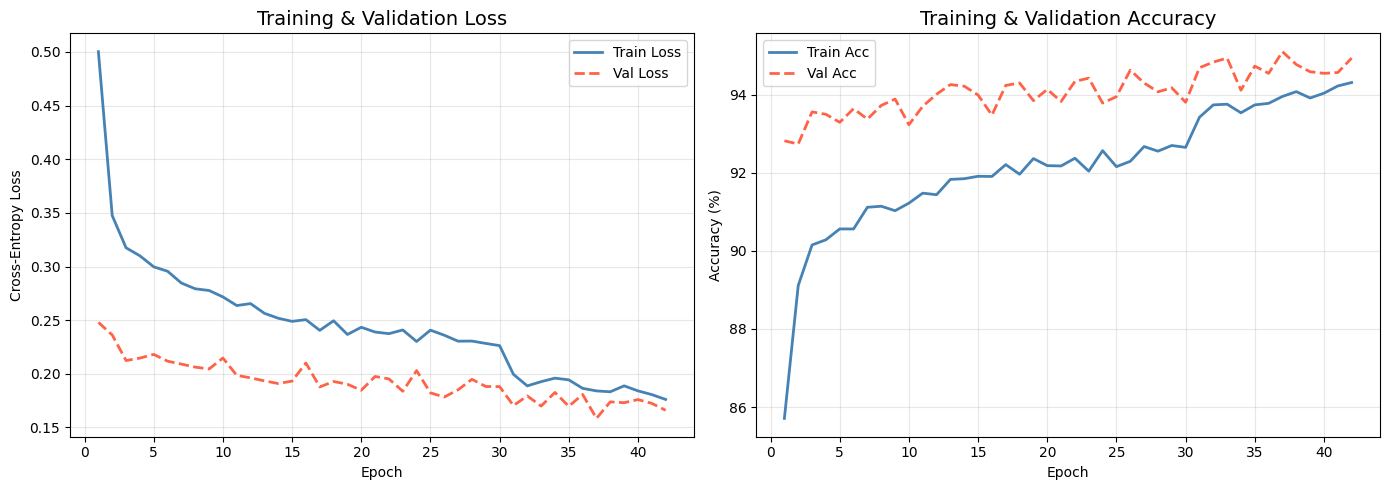

Saved: learning_curves.png


In [33]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(epochs_ran, history["train_loss"], label="Train Loss", color="steelblue", linewidth=2)
ax1.plot(epochs_ran, history["val_loss"],   label="Val Loss",   color="tomato",    linewidth=2, linestyle="--")
ax1.set_title("Training & Validation Loss", fontsize=14)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend(); ax1.grid(alpha=0.3)
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Accuracy curves
ax2.plot(epochs_ran, history["train_acc"], label="Train Acc", color="steelblue", linewidth=2)
ax2.plot(epochs_ran, history["val_acc"],   label="Val Acc",   color="tomato",    linewidth=2, linestyle="--")
ax2.set_title("Training & Validation Accuracy", fontsize=14)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.legend(); ax2.grid(alpha=0.3)
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: learning_curves.png")

## Evaluation on the Held-Out Test Set

**Which part evaluates the model?** This cell.

We compute on the **test set** (data the model has never seen):
- **Accuracy** — overall fraction of correct predictions.
- **Precision** — of all predictions for a class, how many were truly that class.
- **Recall** — of all true members of a class, how many did we find.
- **F1-score** — harmonic mean of precision and recall; useful for imbalanced classes.
- **Confusion matrix** — shows which species are most commonly confused with each other.

In [34]:
def collect_predictions(
    model: nn.Module,
    loader: DataLoader,
) -> Tuple[List[int], List[int]]:
    """
    Run the model over a DataLoader and collect ground-truth labels
    and predicted labels for metric computation.

    Returns:
        (all_labels, all_predictions)
    """
    model.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds   = outputs.argmax(dim=1).cpu().tolist()
            all_preds.extend(preds)
            all_labels.extend(labels.tolist())
    return all_labels, all_preds


y_true, y_pred = collect_predictions(model, test_loader)

test_acc = accuracy_score(y_true, y_pred) * 100
print(f"\n{'='*50}")
print(f"  TEST SET ACCURACY: {test_acc:.2f}%")
print(f"{'='*50}\n")

# Per-class report
report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    digits=3
)
print("Classification Report (Precision / Recall / F1 per class):")
print(report)


  TEST SET ACCURACY: 94.86%

Classification Report (Precision / Recall / F1 per class):
              precision    recall  f1-score   support

      Beetle      0.928     0.976     0.951       290
   Butterfly      0.979     0.956     0.967       294
         Cat      0.939     0.929     0.934       364
         Cow      0.940     0.948     0.944       330
         Dog      0.929     0.959     0.944       314
    Elephant      0.944     0.979     0.961       326
     Gorilla      0.928     0.919     0.924       335
       Hippo      0.965     0.906     0.934       330
      Lizard      0.943     0.984     0.963       317
      Monkey      0.954     0.931     0.942       334
       Mouse      0.932     0.914     0.923       315
       Panda      0.943     0.982     0.962       339
      Spider      0.955     0.949     0.952       293
       Tiger      0.966     0.931     0.948       335
       Zebra      0.988     0.971     0.980       345

    accuracy                          0.949  

## Confusion Matrix

The confusion matrix visualises where the model makes mistakes. Rows are true classes; columns are predicted classes. Perfect predictions fall on the diagonal.

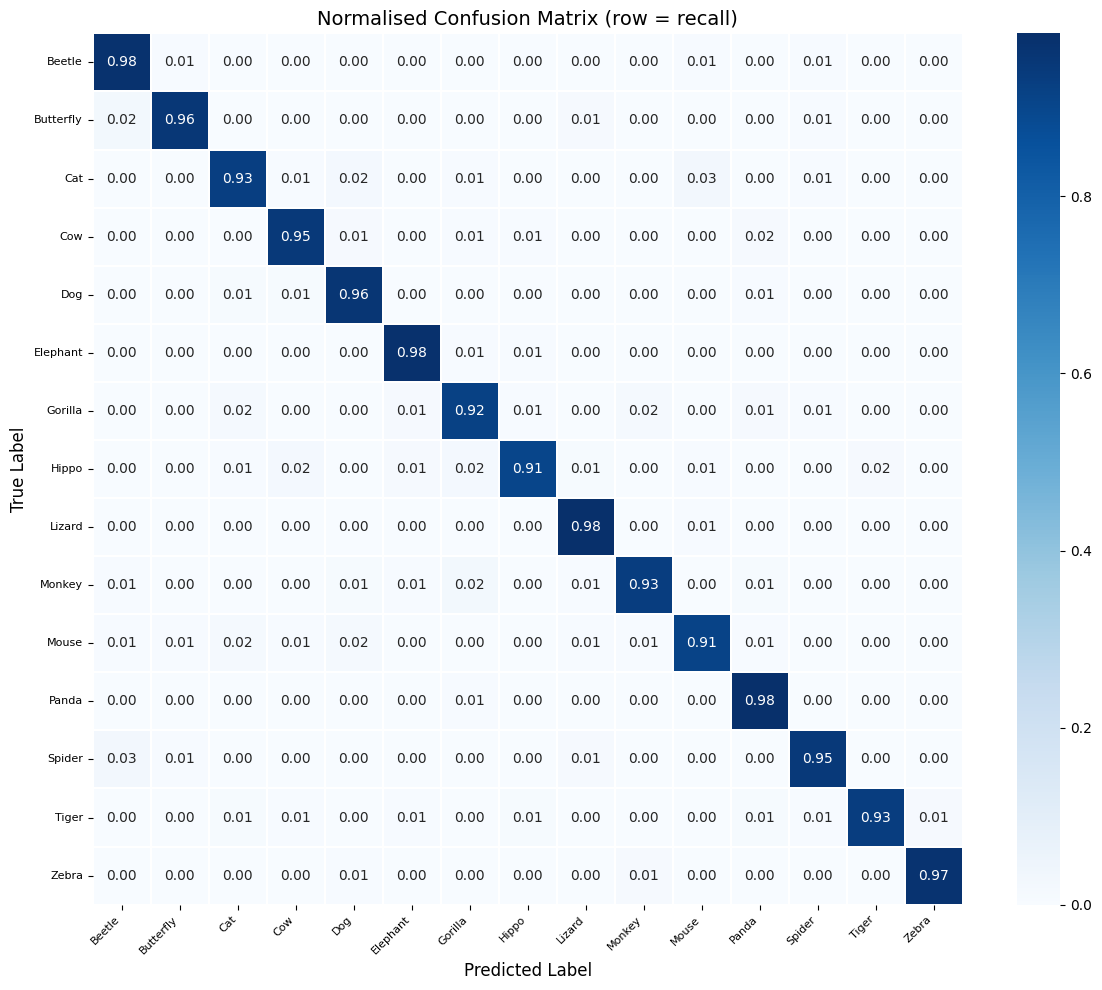

Saved: confusion_matrix.png


In [35]:
cm = confusion_matrix(y_true, y_pred)

# Normalise row-wise so each cell shows recall per class
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(max(12, NUM_CLASSES // 2), max(10, NUM_CLASSES // 2)))
sns.heatmap(
    cm_norm,
    annot=(NUM_CLASSES <= 20),   # only annotate if few classes — avoids clutter
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax,
    linewidths=0.3,
)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label",      fontsize=12)
ax.set_title("Normalised Confusion Matrix (row = recall)", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix.png")

## Top-5 Hardest Classes

Identifying the classes with the lowest per-class recall highlights where the model struggles and guides future work (more data, finer augmentation, etc.).

In [36]:
per_class_recall = cm.diagonal() / cm.sum(axis=1)
df_recall = pd.DataFrame({
    "Species": CLASS_NAMES,
    "Recall":  per_class_recall
}).sort_values("Recall")

print("Top-5 hardest species (lowest recall):")
print(df_recall.head(5).to_string(index=False))

print("\nTop-5 easiest species (highest recall):")
print(df_recall.tail(5).to_string(index=False))

Top-5 hardest species (lowest recall):
Species   Recall
  Hippo 0.906061
  Mouse 0.914286
Gorilla 0.919403
    Cat 0.928571
 Monkey 0.931138

Top-5 easiest species (highest recall):
 Species   Recall
   Zebra 0.971014
  Beetle 0.975862
Elephant 0.978528
   Panda 0.982301
  Lizard 0.984227


## Save Model & Label Map

In [37]:
def save_model_state(model: nn.Module, filepath: str) -> None:
    """
    Save model state dictionary to disk with error handling.

    Args:
        model:    The trained PyTorch model.
        filepath: Destination path for the .pth file.
    """
    try:
        torch.save(model.state_dict(), filepath)
        print(f"Model weights saved → {filepath}")
    except Exception as exc:
        print(f"ERROR saving model: {exc}")
        raise


# Save model weights
save_model_state(model, MODEL_SAVE)

# Save class-index mapping as CSV (useful for inference scripts)
label_map = pd.DataFrame({"index": range(NUM_CLASSES), "species": CLASS_NAMES})
label_map.to_csv("label_map.csv", index=False)
print("Label map saved → label_map.csv")

Model weights saved → wildlife_classifier.pth
Label map saved → label_map.csv


### Location Finetuning
Use this when deploying to a new region with its own species subset.
Only the classifier head is retrained; the backbone stays frozen.

In [38]:
def finetune_for_location(
    checkpoint_path: str,
    new_data_dir: str,
    new_num_classes: int,
    num_epochs: int = 10,
    lr: float = 1e-3,
) -> nn.Module:
    """
    Load a pretrained WildlifeClassifier and finetune its head
    on a new location's species data.

    Args:
        checkpoint_path: Path to the saved .pth file from general training.
        new_data_dir:    Root folder of the new dataset (one subfolder per species).
        new_num_classes: Number of species in the new location.
        num_epochs:      How many epochs to finetune for.
        lr:              Learning rate for the new head.

    Returns:
        Finetuned model.
    """
    # Load new data
    new_dataset = ImageFolder(new_data_dir, transform=train_transform)
    n = len(new_dataset)
    n_val   = int(n * 0.15)
    n_train = n - n_val
    new_train_ds, new_val_ds = random_split(
        new_dataset, [n_train, n_val],
        generator=torch.Generator().manual_seed(SEED)
    )
    new_train_loader = DataLoader(new_train_ds, batch_size=BATCH_SIZE, shuffle=True)
    new_val_loader   = DataLoader(new_val_ds,   batch_size=BATCH_SIZE, shuffle=False)

    # Load general model and swap the classifier head
    ft_model = WildlifeClassifier(num_classes=NUM_CLASSES, freeze_backbone=True).to(device)
    ft_model.load_state_dict(torch.load(checkpoint_path, map_location=device))

    # Replace head with one sized for the new location
    ft_model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(1280, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.2),
        nn.Linear(256, new_num_classes),
    ).to(device)

    # Only train the new head
    ft_optimizer = torch.optim.Adam(ft_model.classifier.parameters(), lr=lr)

    best_val_loss = float("inf")
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = run_epoch(ft_model, new_train_loader, criterion, ft_optimizer, train=True)
        val_loss,   val_acc   = run_epoch(ft_model, new_val_loader,   criterion, train=False)
        print(f"Finetune Epoch {epoch:02d}/{num_epochs}  "
              f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.1f}%  "
              f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.1f}%")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(ft_model.state_dict(), "wildlife_classifier_finetuned.pth")
            print(f"  ✓ Best finetuned model saved")

    ft_model.load_state_dict(torch.load("wildlife_classifier_finetuned.pth", map_location=device))
    return ft_model

In [39]:
# Example usage
# Uncomment and update paths when you have a location-specific dataset:

# finetuned_model = finetune_for_location(
#     checkpoint_path = "wildlife_classifier.pth",
#     new_data_dir    = "path/to/local/species/folder",
#     new_num_classes = 10,   # however many species are in that region
#     num_epochs      = 10,
# )

## Single-Image Inference

Demonstrates how to load the saved model and predict on a single new image — the key use case for camera-trap automation.

In [40]:
from PIL import Image


def predict_species(
    image_path: str,
    model: nn.Module,
    class_names: List[str],
    transform: transforms.Compose,
    top_k: int = 3,
) -> List[Tuple[str, float]]:
    """
    Predict the species in a single image and return the top-k predictions.

    Args:
        image_path:  Path to the input image file.
        model:       Trained WildlifeClassifier.
        class_names: Ordered list of species names.
        transform:   Preprocessing pipeline to apply.
        top_k:       Number of top predictions to return.

    Returns:
        List of (species_name, confidence_percent) tuples, sorted by confidence.
    """
    model.eval()
    img = Image.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)   # add batch dimension

    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).squeeze()

    top_probs, top_indices = probs.topk(top_k)
    results = [
        (class_names[idx.item()], prob.item() * 100)
        for idx, prob in zip(top_indices, top_probs)
    ]
    return results

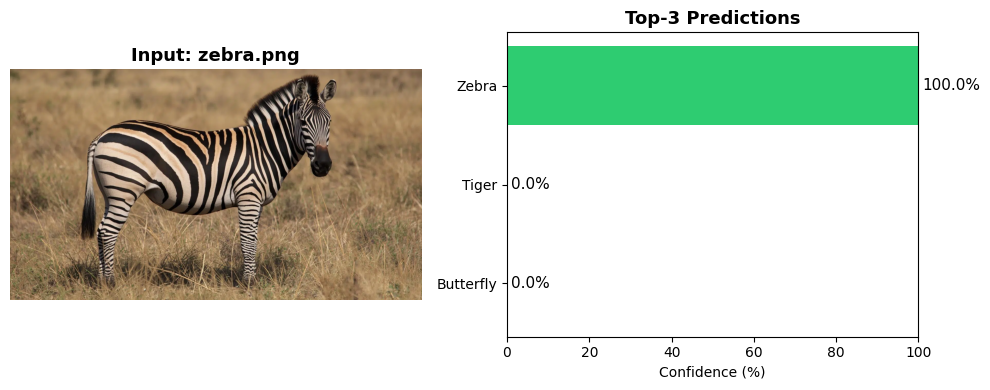

Top prediction : Zebra
Top-3 predictions:
  Zebra                    : 100.0%
  Tiger                    : 0.0%
  Butterfly                : 0.0%


In [47]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Example usage (replace path with any image file)
EXAMPLE_IMAGE = "zebra.png"
predictions = predict_species(EXAMPLE_IMAGE, model, CLASS_NAMES, eval_transform)

# Display
fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(10, 4))

# Image via PIL
img = Image.open(EXAMPLE_IMAGE).convert("RGB")
ax_img.imshow(img)
ax_img.axis('off')
ax_img.set_title(f"Input: {EXAMPLE_IMAGE}", fontsize=13, fontweight='bold')

# Top-3 bar chart
top3_species = [s for s, _ in predictions[:3]]
top3_conf    = [c for _, c in predictions[:3]]
colors = ['#2ecc71' if s.lower() in EXAMPLE_IMAGE.lower() else '#3498db' for s in top3_species]

bars = ax_bar.barh(top3_species[::-1], top3_conf[::-1], color=colors[::-1])
ax_bar.set_xlabel('Confidence (%)')
ax_bar.set_title('Top-3 Predictions', fontsize=13, fontweight='bold')
ax_bar.set_xlim(0, 100)
for bar, val in zip(bars, top3_conf[::-1]):
    ax_bar.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=11)

plt.tight_layout()
plt.show()

print(f"Top prediction : {top3_species[0]}")
print("Top-3 predictions:")
for species, confidence in predictions[:3]:
    print(f"  {species:25s}: {confidence:.1f}%")

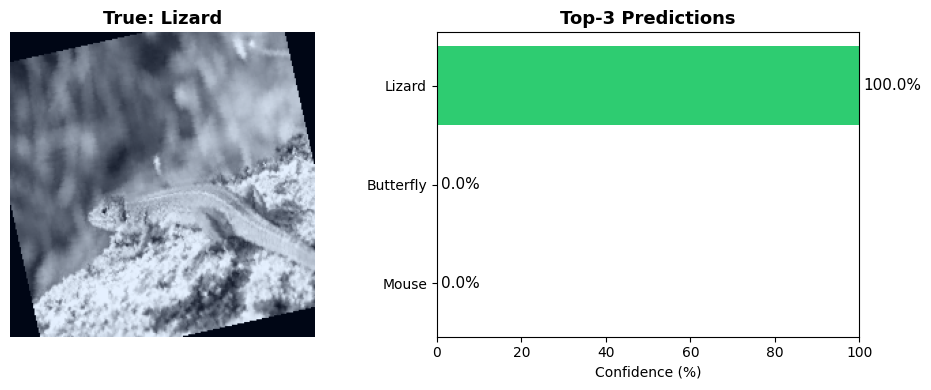

True species  : Lizard
Top-3 predictions:
  Lizard                   : 100.0%
  Butterfly                : 0.0%
  Mouse                    : 0.0%


In [42]:
import matplotlib.pyplot as plt

# Quick sanity check using a test-set image
sample_images, sample_labels = next(iter(test_loader))
sample_img_tensor = sample_images[0].to(device)
model.eval()
with torch.no_grad():
    logits = model(sample_img_tensor.unsqueeze(0))
    probs  = torch.softmax(logits, dim=1).squeeze()
top3 = probs.topk(3)

true_label = CLASS_NAMES[sample_labels[0].item()]

# Display image + predictions
fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(10, 4))

# Image (undo normalization if applied)
img = sample_images[0].permute(1, 2, 0).cpu().numpy()
img = (img - img.min()) / (img.max() - img.min())  # normalize to [0,1] for display
ax_img.imshow(img)
ax_img.set_title(f"True: {true_label}", fontsize=13, fontweight='bold')
ax_img.axis('off')

# Top-3 bar chart
labels = [CLASS_NAMES[i.item()] for i in top3.indices]
values = [p.item() * 100 for p in top3.values]
colors = ['#2ecc71' if labels[i] == true_label else '#3498db' for i in range(3)]
bars = ax_bar.barh(labels[::-1], values[::-1], color=colors[::-1])
ax_bar.set_xlabel('Confidence (%)')
ax_bar.set_title('Top-3 Predictions', fontsize=13, fontweight='bold')
ax_bar.set_xlim(0, 100)
for bar, val in zip(bars, values[::-1]):
    ax_bar.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=11)

plt.tight_layout()
plt.show()

print(f"True species  : {true_label}")
print("Top-3 predictions:")
for idx, prob in zip(top3.indices, top3.values):
    print(f"  {CLASS_NAMES[idx.item()]:25s}: {prob.item()*100:.1f}%")

## Cleanup
To free up memory space taken up during the model training.

In [48]:
import gc
import torch

# Delete large objects if they exist
for var in ['model', 'optimizer', 'scheduler', 'train_loader', 'val_loader', 'test_loader',
            'sample_images', 'sample_labels', 'sample_img_tensor', 'logits', 'probs']:
    if var in dir():
        del var

# Clear CUDA cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

# Force garbage collection
gc.collect()

print(f"GPU memory allocated : {torch.cuda.memory_allocated() / 1e6:.1f} MB")
print(f"GPU memory reserved  : {torch.cuda.memory_reserved()  / 1e6:.1f} MB")
print("✓ Cleanup done")

GPU memory allocated : 33.0 MB
GPU memory reserved  : 107.0 MB
✓ Cleanup done
